# Gradient-comparison plots

Reads `gradient_direction_comparison_grouped.xlsx` (same folder) and makes, **one figure per test**:

1. the three objective functions (unweighted $\chi^2$, weighted $\chi^2$, NLL) vs shots, and
2. the three gradient-direction **cosine similarities** vs shots.

Run all cells. To also save PNGs, pass `save_dir=r"..."` to `per_test_figures(...)`.

In [3]:
# --- ensure openpyxl (needed by pandas to read .xlsx) ---
try:
    import openpyxl  # noqa: F401
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openpyxl"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXCEL_PATH = "gradient_direction_comparison_grouped.xlsx"   # same folder as this notebook

df = pd.read_excel(EXCEL_PATH, sheet_name=0)
df["test_index"] = df["test_index"].ffill().astype(int)     # first row of each group holds the index

def _to_shots(v):
    s = str(v).strip().lower().replace(",", "")
    return np.inf if s.startswith("inf") else float(s)
df["shots"] = df["shots_per_circuit"].map(_to_shots)

# x-axis positions: finite shots on a log axis; the infinite/statevector point one decade past, tick = infinity
INF_POS = 1e9
df["xpos"] = df["shots"].replace(np.inf, INF_POS)
_finite = sorted(df.loc[np.isfinite(df["shots"]), "shots"].unique())
XTICKS  = _finite + [INF_POS]
XLABELS = [f"$10^{{{int(np.log10(s))}}}$" for s in _finite] + [r"$\infty$"]

df.head()


,test_index,shots_per_circuit,unweighted_chi_square_hfun,weighted_chi_square_hfun,negative_loglikelihood_hfun,cosine_unweighted_vs_weighted,cosine_unweighted_vs_nll,cosine_weighted_vs_nll,unweighted_gradient_norm,weighted_gradient_norm,nll_gradient_norm,shots,xpos
0,1,100,51.369640,26315.355488,9.133461e+05,0.560048,0.560048,1.0,143.856446,8.962453e+04,4.481226e+04,100.0,100.0
1,1,"1,000",5.171333,26227.946942,9.129264e+06,0.656629,0.656629,1.0,40.741988,2.781948e+05,1.390974e+05,1000.0,1000.0
2,1,"10,000",0.515654,26224.352609,9.130152e+07,0.539165,0.539165,1.0,12.012661,8.309042e+05,4.154521e+05,10000.0,10000.0
3,1,"100,000",0.051617,26468.423817,9.130198e+08,0.660303,0.660303,1.0,3.552977,2.941969e+06,1.470985e+06,100000.0,100000.0
4,1,"1,000,000",0.005093,26289.690860,9.130254e+09,0.494117,0.494117,1.0,1.170642,8.255781e+06,4.127891e+06,1000000.0,1000000.0


In [4]:
# One figure per test, with all given series overlaid on a single axis.
OKABE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"]  # colorblind-safe, fixed order

def per_test_figures(specs, ylabel, title, log_y=False, hline=None, ylim=None, save_dir=None):
    """specs = list of (column_name, legend_label)."""
    for test in sorted(df["test_index"].unique()):
        g = df[df["test_index"] == test].sort_values("xpos")
        fig, ax = plt.subplots(figsize=(7.5, 5.2))
        for (col, lbl), color in zip(specs, OKABE):
            y = g[col].astype(float).values.copy()
            if log_y:
                y = np.where(y > 0, y, np.nan)   # log axis cannot show 0 / negatives
            ax.plot(g["xpos"], y, "o-", ms=6, lw=1.9, color=color, label=lbl)
        ax.set_xscale("log")
        if log_y:
            ax.set_yscale("log")
        if hline is not None:
            ax.axhline(hline, color="0.6", lw=1.0, ls="--")
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_xticks(XTICKS)
        ax.set_xticklabels(XLABELS)
        ax.axvline(3.16e8, color="0.85", lw=0.8, ls=":")   # visual break before the infinite point
        ax.grid(True, which="major", color="0.9", lw=0.6)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        ax.set_xlabel("shots per circuit")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Test {test} - {title}")
        ax.legend(frameon=False)
        fig.tight_layout()
        if save_dir:
            import os
            fig.savefig(os.path.join(save_dir, f"{title.replace(' ', '_')}_test{test}.png"),
                        dpi=150, bbox_inches="tight")
        plt.show()


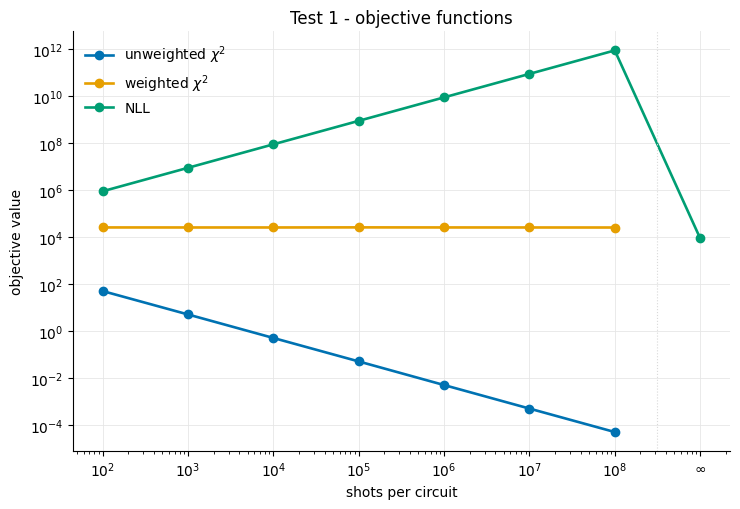

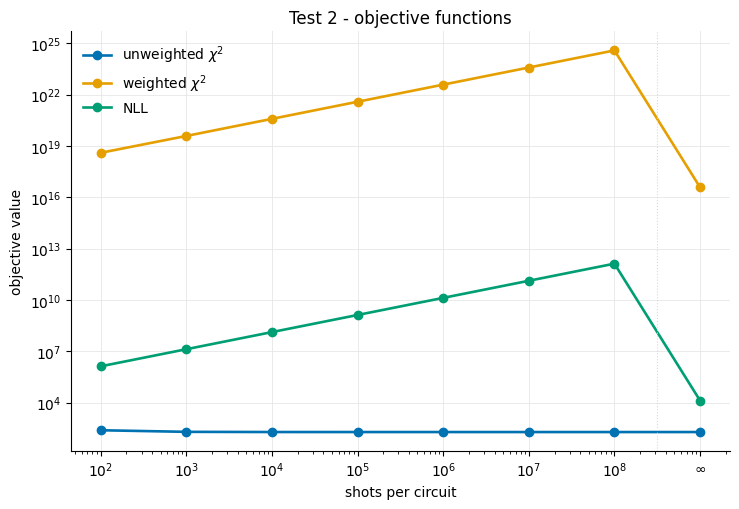

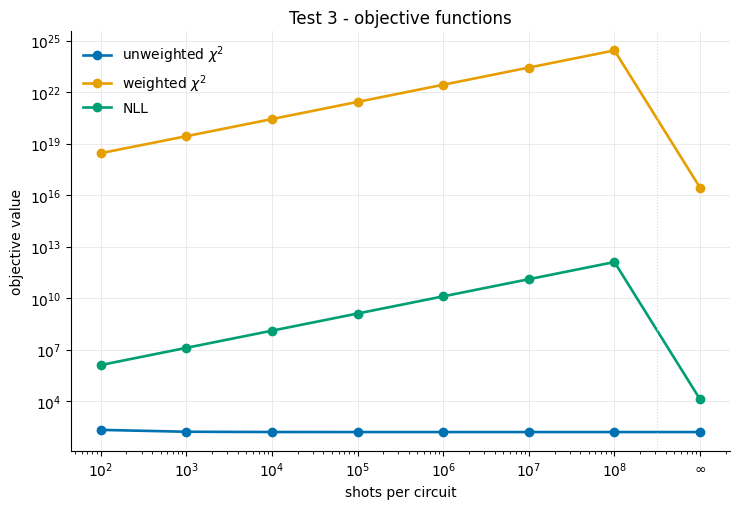

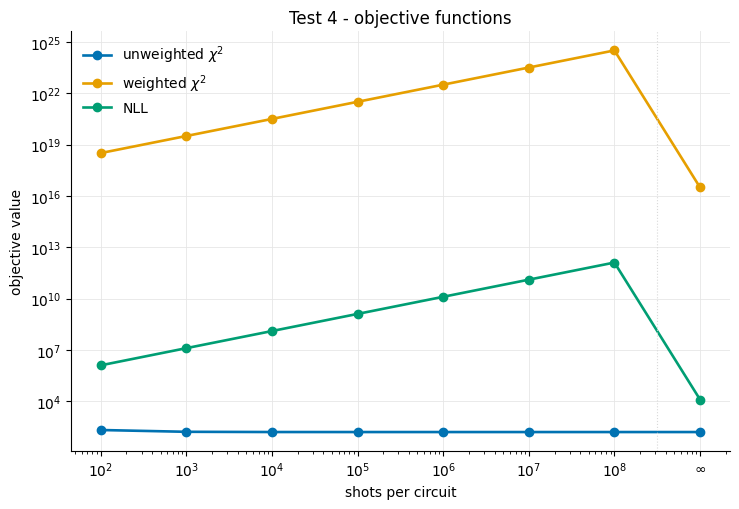

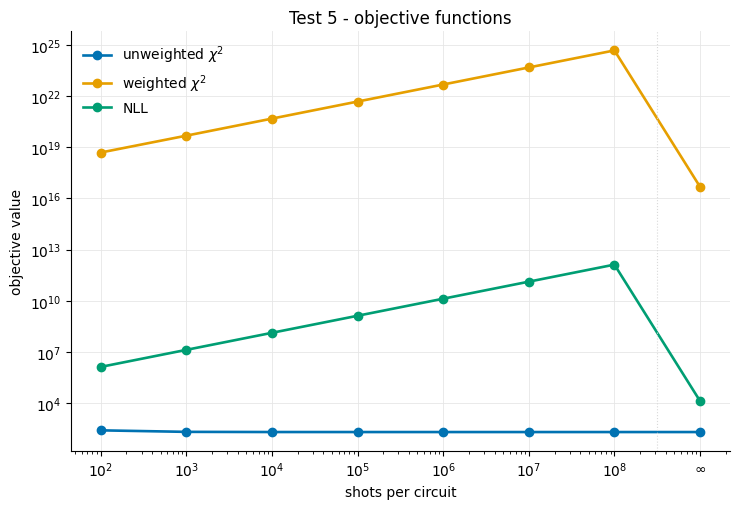

In [5]:
# --- Objective functions (log scale; they span ~20 decades) ---
per_test_figures(
    [("unweighted_chi_square_hfun",  r"unweighted $\chi^2$"),
     ("weighted_chi_square_hfun",    r"weighted $\chi^2$"),
     ("negative_loglikelihood_hfun", "NLL")],
    ylabel="objective value",
    title="objective functions",
    log_y=True,
)


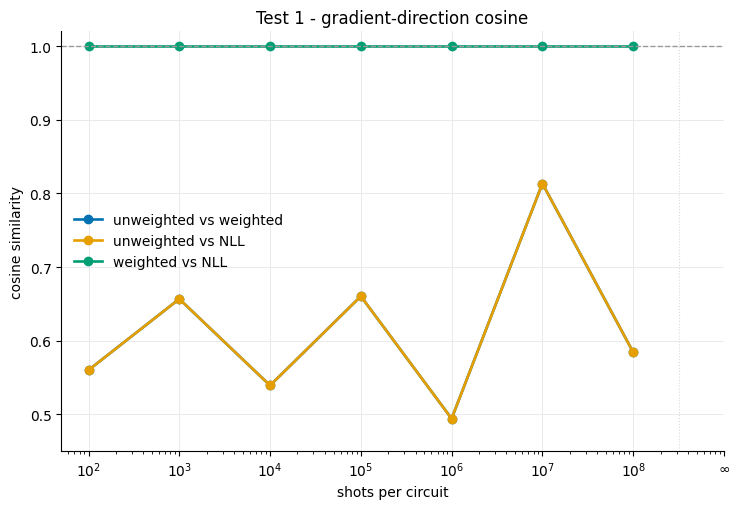

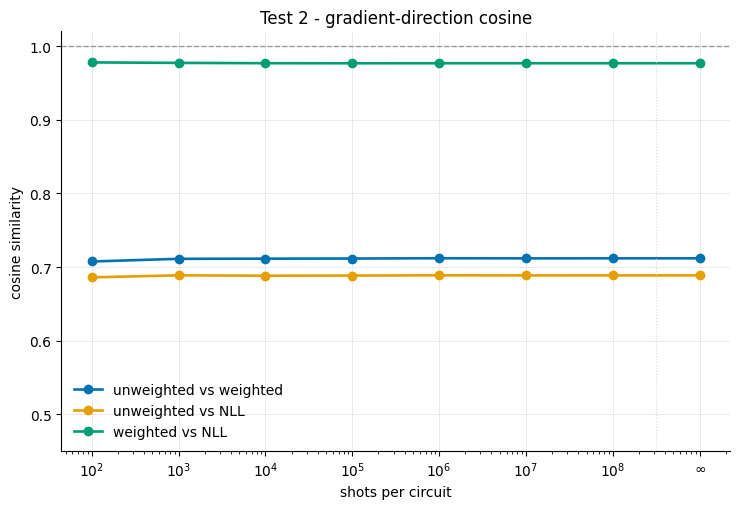

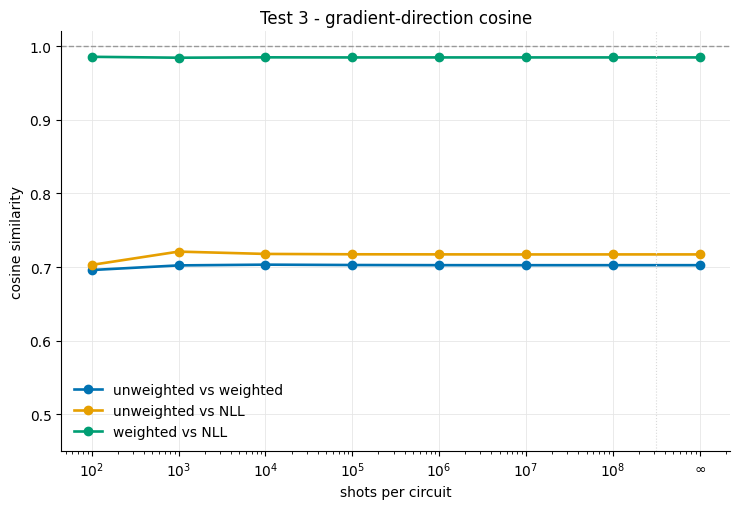

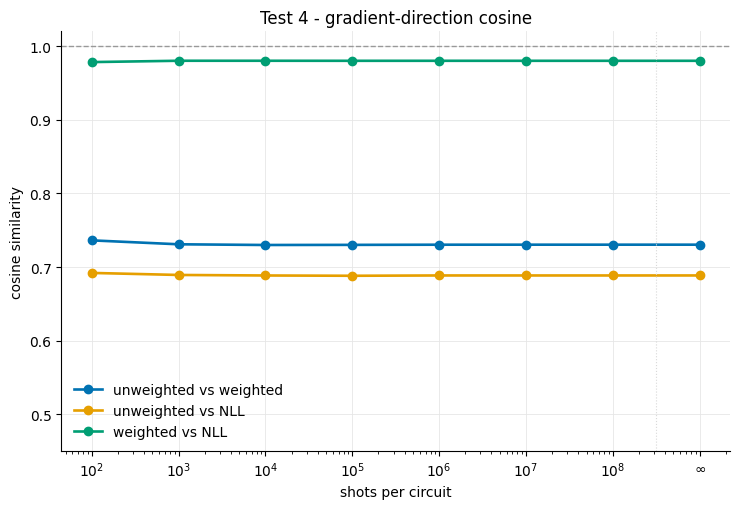

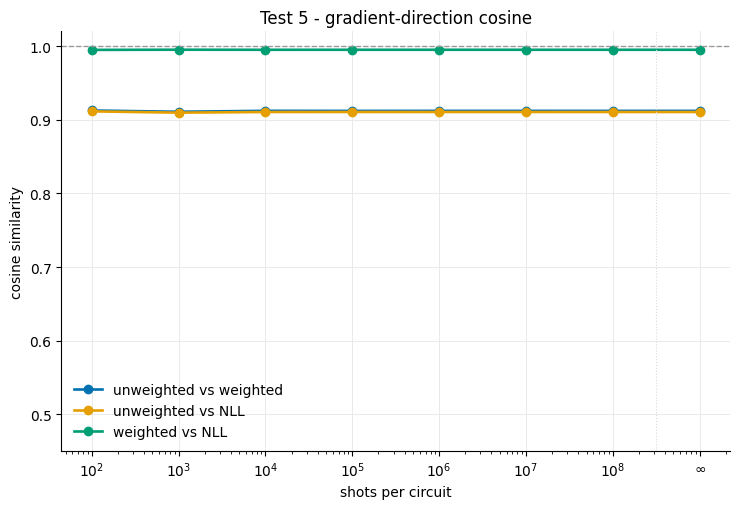

In [6]:
# --- Gradient-direction cosine similarity (1.0 = identical direction) ---
per_test_figures(
    [("cosine_unweighted_vs_weighted", "unweighted vs weighted"),
     ("cosine_unweighted_vs_nll",      "unweighted vs NLL"),
     ("cosine_weighted_vs_nll",        "weighted vs NLL")],
    ylabel="cosine similarity",
    title="gradient-direction cosine",
    log_y=False,
    hline=1.0,
    ylim=(0.45, 1.02),
)
